In [1]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '../..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble, mean_field_dens_propagation, derrida_map_analytical, hamming_weight, boolean_sens, mean_field_slope

%load_ext autoreload
%autoreload 2

# Sensitivity to degree

In [ ]:
num_nodes = 2500
degree = 8
resolution = 9

beta, sigma = (488, 464)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)

configs_array = np.load(f"data/configs_array_degree_N{num_nodes}_{model.__str__()}_degree{degree}.npy")
with open(f"data/configs_switched_list_degree_N{num_nodes}_{model.__str__()}_degree{degree}.pickle", 'rb') as handle:
    configs_switched_list = pickle.load(handle)

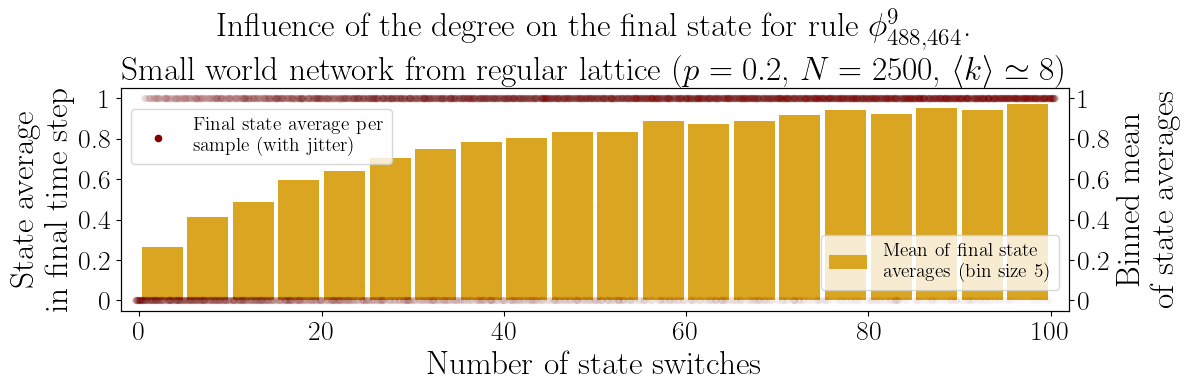

In [ ]:
SAVEFIG=False

fig, ax1 = plt.subplots(1,1,figsize=(12,4))
fontsize=20
# Create the secondary y-axis
ax2 = ax1.twinx()

alpha=0.01
max_switches = 100

# open list where all y values are kept (which we will average over later)
y_vals_total = []
# loop over the 30 graphs
for i, configs_switched in enumerate(configs_switched_list):
    if configs_switched is not None:
        # loop over the initial conditions that led to extinction
        number_of_extinctions = configs_switched.shape[1]
        for sample_idx in range(number_of_extinctions):
            hjitter = np.random.random(max_switches+1)-0.5
            x_vals = np.arange(max_switches+1)+hjitter
            y_vals = np.mean(configs_switched[:,sample_idx,-1], axis=(1,2))
            y_vals_total.append(y_vals)
            label=None
            if i==0 and sample_idx==0:
                label='Final state average per\nsample (with jitter)'
            ax1.scatter(x_vals, y_vals, color='maroon', alpha=alpha, s=20, label=label, zorder=10)

# Average over all samples
y_vals_avg = np.mean(y_vals_total, axis=0)  # shape: (max_switches + 1,)

# Bin into intervals of 5
bin_width = 5
bins = np.arange(0, max_switches + 2, bin_width)  # +2 to include max_switches
bin_centers = (bins[:-1] + bins[1:]) / 2

binned_means = []
for i in range(len(bins) - 1):
    start, end = bins[i], bins[i+1]
    bin_avg = np.mean(y_vals_avg[start:end])
    binned_means.append(bin_avg)

# Overlay bar chart
ax2.bar(bin_centers, binned_means, width=bin_width*0.9, color='goldenrod', alpha=1, zorder=0, label=f'Mean of final state\naverages (bin size ${bin_width}$)')

# make axis pretty
ax1.set_ylim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax1.set_xlim(-2, 102)
xticks = [0, 20, 40, 60, 80, 100]
yticks = [0, .2, .4, .6, .8, 1]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, fontsize=fontsize)
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
ax1.set_yticklabels(yticks, fontsize=fontsize)
ax2.set_yticklabels(yticks, fontsize=fontsize)
ax1.set_xlabel("Number of state switches", fontsize=fontsize+4)
ax1.set_ylabel(f"State average\nin final time step", fontsize=fontsize+4)
ax2.set_ylabel(f"Binned mean\nof state averages", fontsize=fontsize+4)

legend = ax1.legend(loc='upper left', bbox_to_anchor=(0,.95), fontsize=fontsize-6)
for handle in legend.legend_handles:
    handle.set_alpha(1)
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.05), fontsize=fontsize-6)

# make sure the scatter plot is in front of the bar plot
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)  # This is critical!

# set a title
ax1.set_title(f"Influence of the degree on the final state for rule {model.__str__(latex=True)}\nSmall world networks from regular lattice ($p=0.2$, $N={num_nodes}$, $\\langle k \\rangle \\simeq 8$)", fontsize=fontsize+4)

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f"figures/influence-of-degree-on-outcome.pdf")

Note that some node properties are highly correlated, especially for a Watts-Strogatz network.